## 1. Plotting the Response Spectrum

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# 1. Load the Dataset
file_path = "NGAsub_MegaFlatfile_RotD50_050_R211022_public.xlsx"
df = pd.read_excel(file_path)

In [ ]:
# 2. Data Screening / Cleaning
# We filter the data based on engineering requirements to ensure only high-quality, relevant data is used.
# - M >= 4: Only 'significant' earthquakes that cause structural response.
# - Rjb (0-500km): Focus on distances where shaking is typically measurable and impactful.
# - Vs30 > 0: Ensures soil stiffness data is present and valid.
# - Fault_Type > 0: Ensures the seismic source mechanism is identified.
df_fil = df[
    (df['Earthquake_Magnitude'] >= 4) &
    (df['Rjb_km'] >= 0) &
    (df['Rjb_km'] <= 500) &
    (df['Vs30_Selected_for_Analysis_m_s'] > 0) &
    (df['Fault_Type'] > 0)
].copy()

In [ ]:
# 3. Identify Spectral Acceleration Columns
# Spectral values are stored in columns starting with 'T' (Period) and ending with 'S' (Seconds).
time_cols = [col for col in df_fil.columns if col.startswith('T') and col.endswith('S')]

# 4. Parse Column Names into Numeric Periods
# The computer sees "T0pt010S" as text. We must convert it to the number 0.010 for the X-axis.
def parse_time_period(col_name):
    # Strip 'T' and 'S', replace 'pt' with a decimal point
    return float(col_name[1:-1].replace('pt', '.'))

# Create a list of periods corresponding to the column names
periods = [parse_time_period(col) for col in time_cols]

print(periods)

[0.01, 0.02, 0.022, 0.025, 0.029, 0.03, 0.032, 0.035, 0.036, 0.04, 0.042, 0.044, 0.045, 0.046, 0.048, 0.05, 0.055, 0.06, 0.065, 0.067, 0.07, 0.075, 0.08, 0.085, 0.09, 0.095, 0.1, 0.11, 0.12, 0.13, 0.133, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2, 0.22, 0.24, 0.25, 0.26, 0.28, 0.29, 0.3, 0.32, 0.34, 0.35, 0.36, 0.38, 0.4, 0.42, 0.44, 0.45, 0.46, 0.48, 0.5, 0.55, 0.6, 0.65, 0.667, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.2, 2.4, 2.5, 2.6, 2.8, 3.0, 3.2, 3.4, 3.5, 3.6, 3.8, 4.0, 4.2, 4.4, 4.6, 4.8, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 20.0]


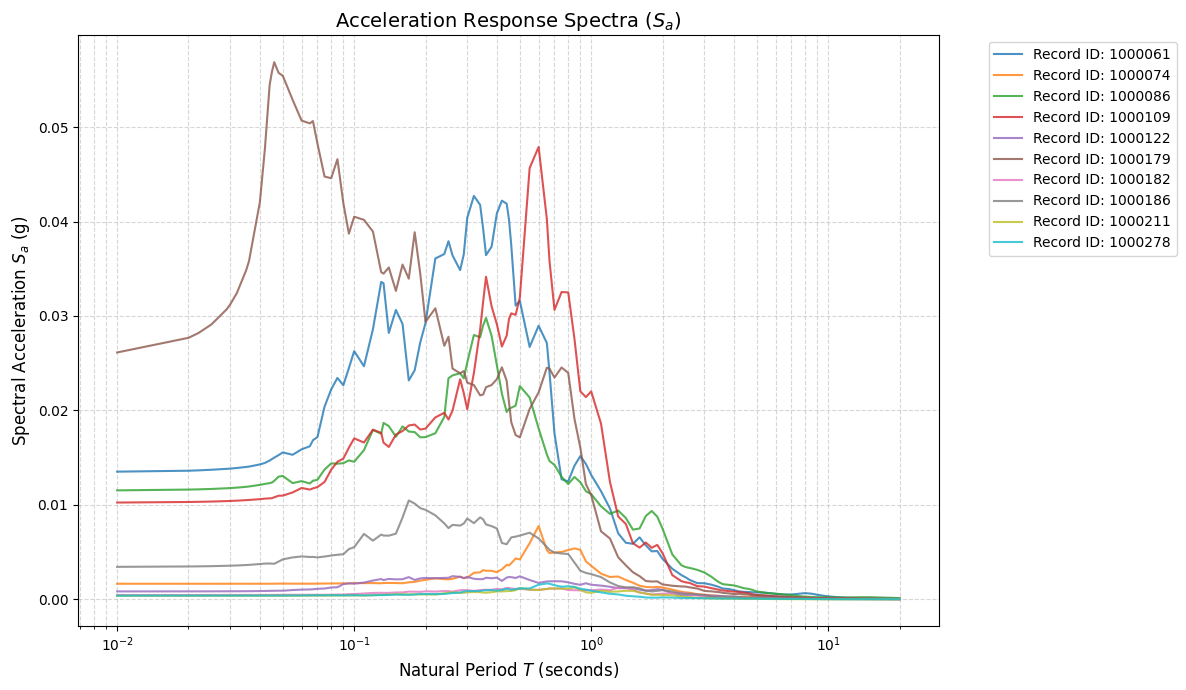

In [ ]:
# 5. Sort the Data by Period
sorted_indices = np.argsort(periods)
sorted_cols = [time_cols[i] for i in sorted_indices]
sorted_periods = [periods[i] for i in sorted_indices]

# 6. Visualization
plt.figure(figsize=(12, 7))
for i in range(min(10, len(df_fil))):
    # Extract the Spectral Acceleration (Sa) values for one earthquake record
    sa_values = df_fil.iloc[i][sorted_cols].values
    plt.plot(sorted_periods, sa_values, label=f'Record ID: {df_fil.iloc[i]["NGAsubRSN"]}', alpha=0.8)

plt.xscale('log')
# plt.yscale('log')

plt.title('Acceleration Response Spectra ($S_a$)', fontsize=14)
plt.xlabel('Natural Period $T$ (seconds)', fontsize=12)
plt.ylabel('Spectral Acceleration $S_a$ (g)', fontsize=12)

# Add gridlines
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()

plt.show()

## 2. Scatter Plots

### 2.1 Magnitude vs PSA@0.1s

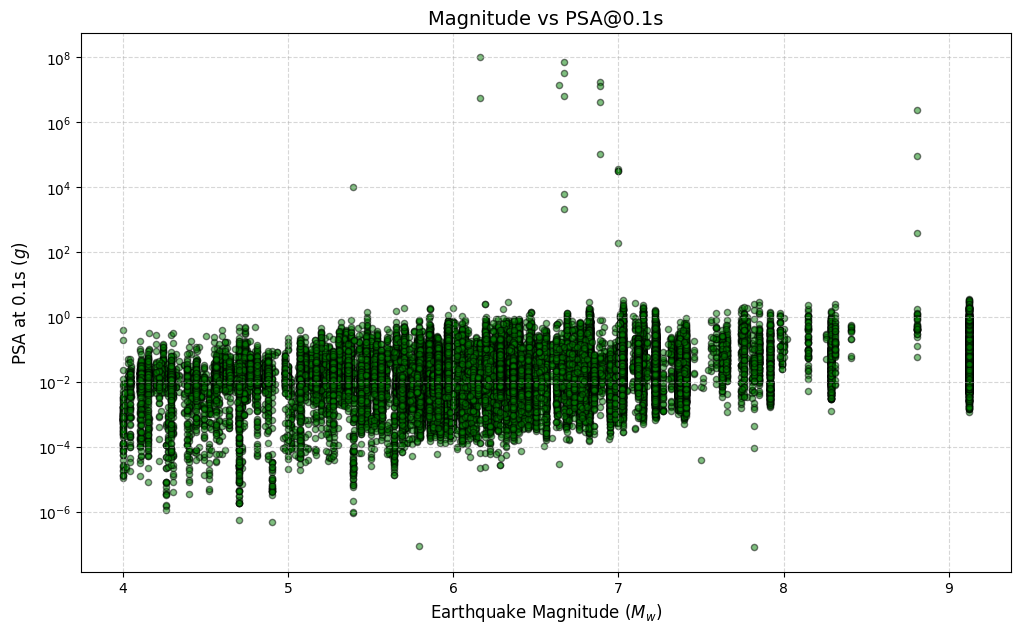

In [ ]:
# 1. Extract the variables for the scatter plot
# We use T0pt100S for PSA@0.1sec
magnitude = df_fil['Earthquake_Magnitude']
psa_01 = df_fil['T0pt100S']

# 2. Create the Plot
plt.figure(figsize=(12, 7))

plt.scatter(magnitude, psa_01, alpha=0.5, edgecolors='k', s=20, color='green')

plt.yscale('log')

plt.title('Magnitude vs PSA@0.1s', fontsize=14)
plt.xlabel('Earthquake Magnitude ($M_w$)', fontsize=12)
plt.ylabel('PSA at 0.1s ($g$)', fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.show()

### 2.2 Rupture vs PSA@0.1s

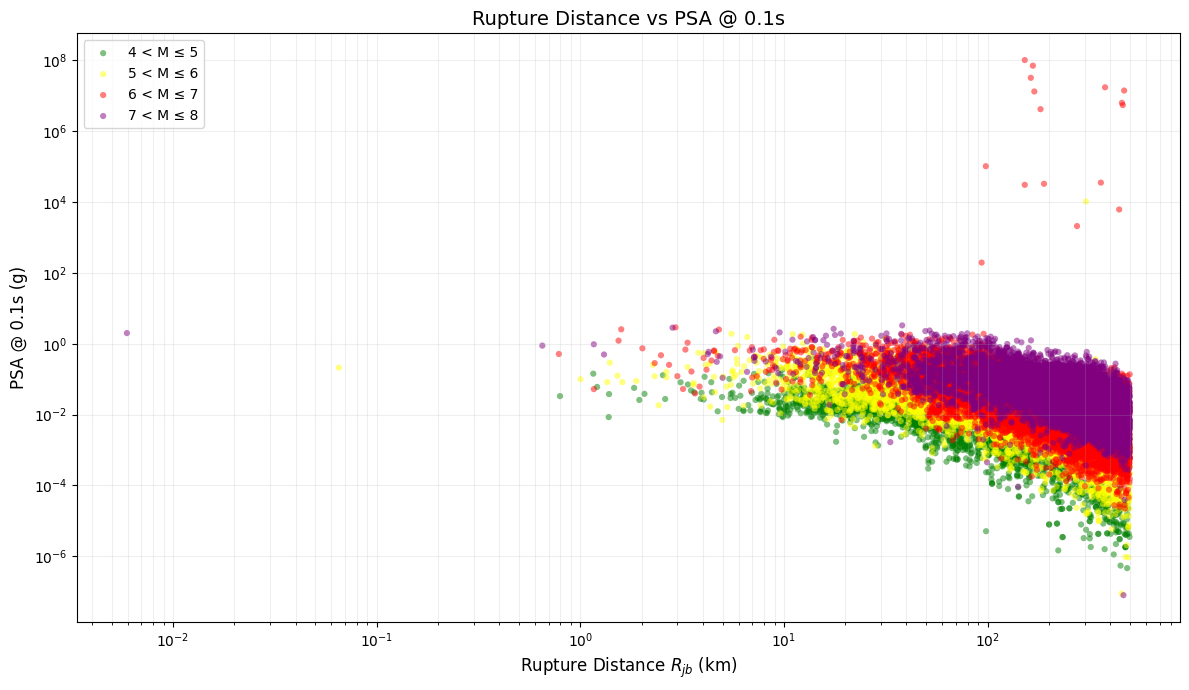

In [ ]:
# 1. Define Magnitude Bins and Colors
# We define ranges to see how larger quakes decay differently than smaller ones.
bins = [
    {'range': (4, 5), 'color': 'green', 'label': '4 < M ≤ 5'},
    {'range': (5, 6), 'color': 'yellow', 'label': '5 < M ≤ 6'},
    {'range': (6, 7), 'color': 'red', 'label': '6 < M ≤ 7'},
    {'range': (7, 8), 'color': 'purple', 'label': '7 < M ≤ 8'}
]

# 2. Create the Plot
plt.figure(figsize=(12, 7))

for b in bins:
    mask = (df_fil['Earthquake_Magnitude'] > b['range'][0]) & (df_fil['Earthquake_Magnitude'] <= b['range'][1])
    subset = df_fil[mask]

    plt.scatter(
        subset['Rjb_km'],
        subset['T0pt100S'],
        color=b['color'],
        label=b['label'],
        alpha=0.5,
        s=20,
        edgecolors='none'
    )

# 3. Scientific Formatting
plt.xscale('log') # Distance is always viewed on a log scale
plt.yscale('log') # PSA is always viewed on a log scale

plt.title('Rupture Distance vs PSA @ 0.1s', fontsize=14)
plt.xlabel('Rupture Distance $R_{jb}$ (km)', fontsize=12)
plt.ylabel('PSA @ 0.1s (g)', fontsize=12)

plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend(loc='upper left', frameon=True)
plt.tight_layout()

plt.show()

### 2.3 Velocity vs PSA@0.1s

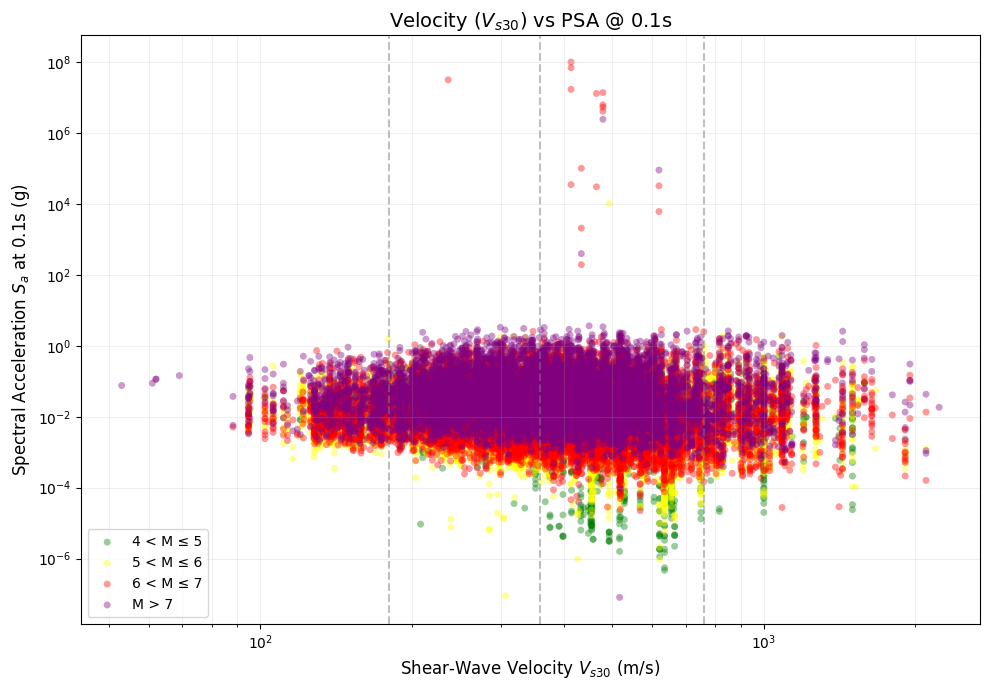

In [ ]:
# 1. Define Magnitude Bins and Colors for ranges
bins = [
    {'range': (4, 5), 'color': 'green', 'label': '4 < M ≤ 5'},
    {'range': (5, 6), 'color': 'yellow', 'label': '5 < M ≤ 6'},
    {'range': (6, 7), 'color': 'red', 'label': '6 < M ≤ 7'},
    {'range': (7, 9.5), 'color': 'purple', 'label': 'M > 7'}
]

# 2. Create the Scatter Plot
plt.figure(figsize=(10, 7))

for b in bins:
    mask = (df_fil['Earthquake_Magnitude'] > b['range'][0]) & (df_fil['Earthquake_Magnitude'] <= b['range'][1])
    subset = df_fil[mask]

    plt.scatter(
        subset['Vs30_Selected_for_Analysis_m_s'],
        subset['T0pt100S'],
        color=b['color'],
        label=b['label'],
        alpha=0.4,
        s=25,
        edgecolors='none'
    )

# 3. Scientific Formatting
plt.xscale('log') # Velocity is plotted on log scale
plt.yscale('log') # Shaking intensity is always log scale

plt.title('Velocity ($V_{s30}$) vs PSA @ 0.1s', fontsize=14)
plt.xlabel('Shear-Wave Velocity $V_{s30}$ (m/s)', fontsize=12)
plt.ylabel('Spectral Acceleration $S_a$ at 0.1s (g)', fontsize=12)

# Adding NEHRP Site Class boundaries for context
plt.axvline(x=180, color='gray', linestyle='--', alpha=0.5) # Class D/E boundary
plt.axvline(x=360, color='gray', linestyle='--', alpha=0.5) # Class C/D boundary
plt.axvline(x=760, color='gray', linestyle='--', alpha=0.5) # Rock boundary

plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend(loc='lower left', frameon=True)
plt.tight_layout()

plt.show()

## 3. Fitting a Linear Regression for a Ground Motion Prediction Equation (GMPE)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

/Users/azizulhoque/miniforge3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/azizulhoque/miniforge3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/azizulhoque/miniforge3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


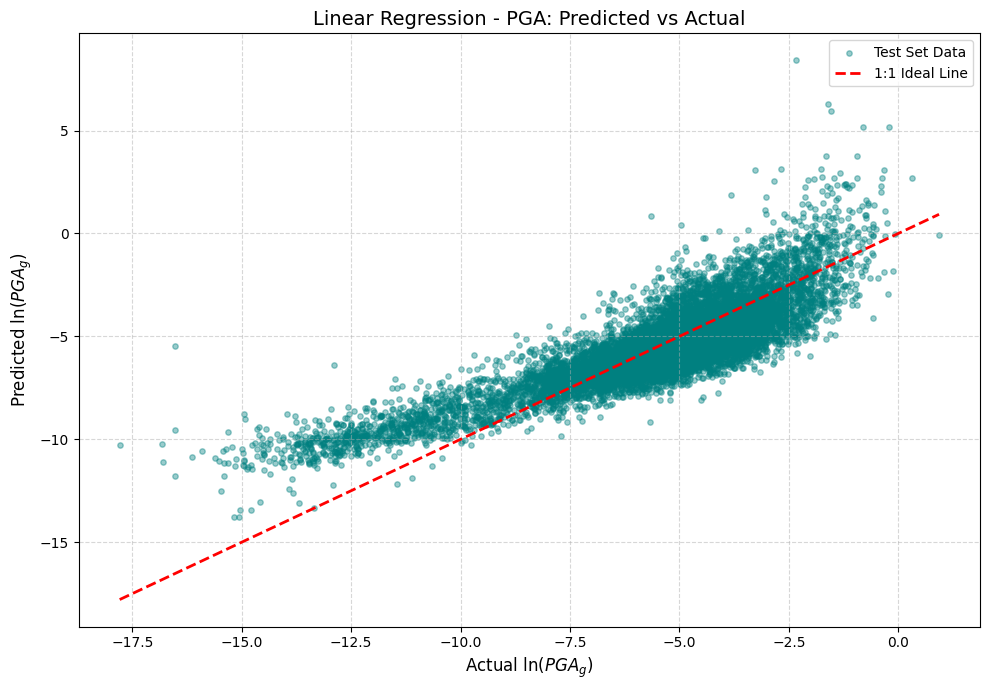

/Users/azizulhoque/miniforge3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/azizulhoque/miniforge3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/azizulhoque/miniforge3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


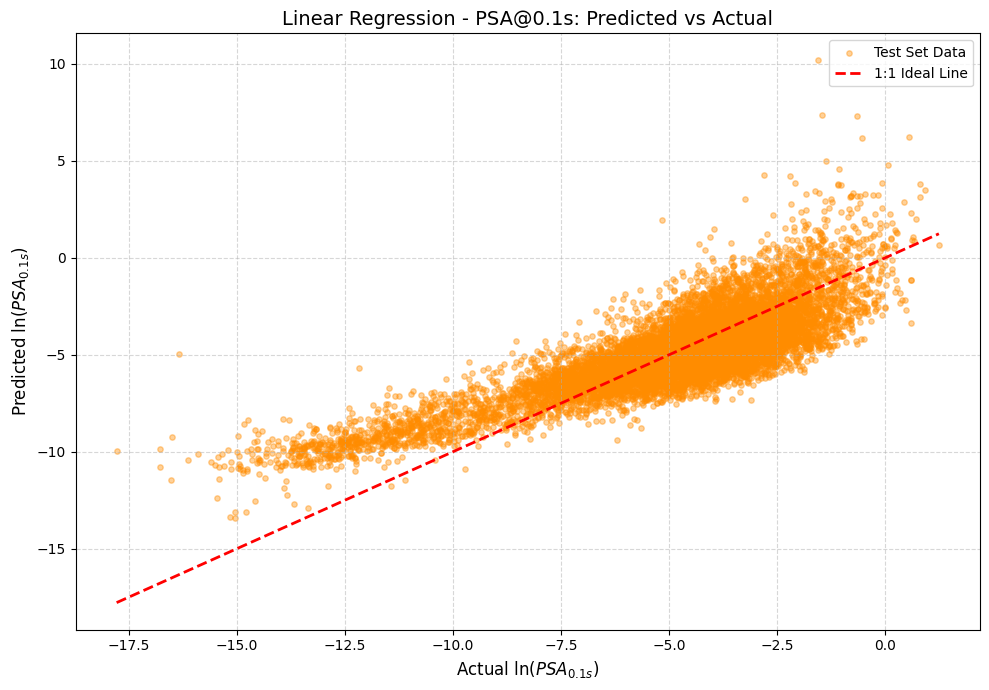

PGA Test R^2 Score: 0.7028
PSA@0.1s Test R^2 Score: 0.6614


In [ ]:
df_fil = df[
    (df['Earthquake_Magnitude'] >= 4) &
    (df['Rjb_km'] > 0) &
    (df['Vs30_Selected_for_Analysis_m_s'] > 0) &
    (df['Hypocenter_Depth_km'] > 0) &
    (df['PGA_g'] > 0) &
    (df['T0pt100S'] > 0) &
    (df['T0pt100S'] < 100)
].copy()

# Feature Engineering
# We define our predictors according to the GMPE requirements.
X = pd.DataFrame()
X['Magnitude'] = df_fil['Earthquake_Magnitude']
X['log_R'] = np.log(df_fil['Rjb_km'])
X['log_Vs'] = np.log(df_fil['Vs30_Selected_for_Analysis_m_s'])
X['Focal'] = df_fil['Hypocenter_Depth_km']

# Target Preparation
# We predict the natural log (ln) of the shaking intensities.
y_pga = np.log(df_fil['PGA_g'])
y_psa = np.log(df_fil['T0pt100S'])

# Scaling
# We use StandardScaler to normalize the feature ranges.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split (80% Training, 20% Testing)
X_train, X_test, y_train_pga, y_test_pga = train_test_split(X_scaled, y_pga, test_size=0.2, random_state=42)
_, _, y_train_psa, y_test_psa = train_test_split(X_scaled, y_psa, test_size=0.2, random_state=42)

# Fit Standard Linear Regression
# We fit two separate models for the two different targets.
model_pga = LinearRegression().fit(X_train, y_train_pga)
model_psa = LinearRegression().fit(X_train, y_train_psa)

# Actual vs. Predicted
plt.figure(figsize=(10, 7))
# PGA Plot
y_pred_pga = model_pga.predict(X_test)
plt.scatter(y_test_pga, y_pred_pga, alpha=0.4, s=15, color='teal', label='Test Set Data')
plt.plot([y_test_pga.min(), y_test_pga.max()], [y_test_pga.min(), y_test_pga.max()], 'r--', lw=2, label='1:1 Ideal Line')

plt.title(r'Linear Regression - PGA: Predicted vs Actual', fontsize=14)
plt.xlabel(r'Actual $\ln(PGA_g)$', fontsize=12)
plt.ylabel(r'Predicted $\ln(PGA_g)$', fontsize=12)
plt.grid(True, ls='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# PSA@0.1s Plot
plt.figure(figsize=(10, 7))
y_pred_psa = model_psa.predict(X_test)
plt.scatter(y_test_psa, y_pred_psa, alpha=0.4, s=15, color='darkorange', label='Test Set Data')
plt.plot([y_test_psa.min(), y_test_psa.max()], [y_test_psa.min(), y_test_psa.max()], 'r--', lw=2, label='1:1 Ideal Line')

plt.title(r'Linear Regression - PSA@0.1s: Predicted vs Actual', fontsize=14)
plt.xlabel(r'Actual $\ln(PSA_{0.1s})$', fontsize=12)
plt.ylabel(r'Predicted $\ln(PSA_{0.1s})$', fontsize=12)
plt.grid(True, ls='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

# Performance Metrics Output
print(f"PGA Test R^2 Score: {r2_score(y_test_pga, y_pred_pga):.4f}")
print(f"PSA@0.1s Test R^2 Score: {r2_score(y_test_psa, y_pred_psa):.4f}")

## 4. ANN Model

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

In [ ]:
# Feature Engineering
X = pd.DataFrame()
X['M'] = df_fil['Earthquake_Magnitude']
X['logR'] = np.log10(df_fil['Rjb_km'])
X['logVs'] = np.log10(df_fil['Vs30_Selected_for_Analysis_m_s'])
X['Focal'] = df_fil['Hypocenter_Depth_km']

# Targets: Natural log (ln) of PGA and PSA@0.1s for log-normal distribution
y = np.log(df_fil[['PGA_g', 'T0pt100S']])

# Train-Test Split and Scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Architecture
def create_tuned_model(learning_rate=0.001, neurons=64):
    model = models.Sequential([
        layers.Input(shape=(4,)),
        layers.Dense(neurons, activation='relu'),
        layers.Dense(neurons // 2, activation='relu'),
        layers.Dense(2) # Predicting both ln(PGA) and ln(PSA)
    ])
    model.compile(optimizer=optimizers.Adam(learning_rate=learning_rate), loss='mse')
    return model

# Simple Hyperparameter Search
# We loop through learning rates and neuron counts to find the most stable fit
best_mse = float('inf')
best_model = None

print("Tuning hyperparameters...")
for lr in [0.01, 0.001]:
    for n in [32, 64, 128]:
        temp_model = create_tuned_model(learning_rate=lr, neurons=n)
        temp_model.fit(X_train_scaled, y_train, epochs=30, verbose=0)
        mse = temp_model.evaluate(X_test_scaled, y_test, verbose=0)
        if mse < best_mse:
            best_mse = mse
            best_model = temp_model

# Final Training with Best Parameters
# Validation split helps monitor for overfitting during the 100 epochs
history = best_model.fit(X_train_scaled, y_train, epochs=100, validation_split=0.2, verbose=0)


Tuning hyperparameters...


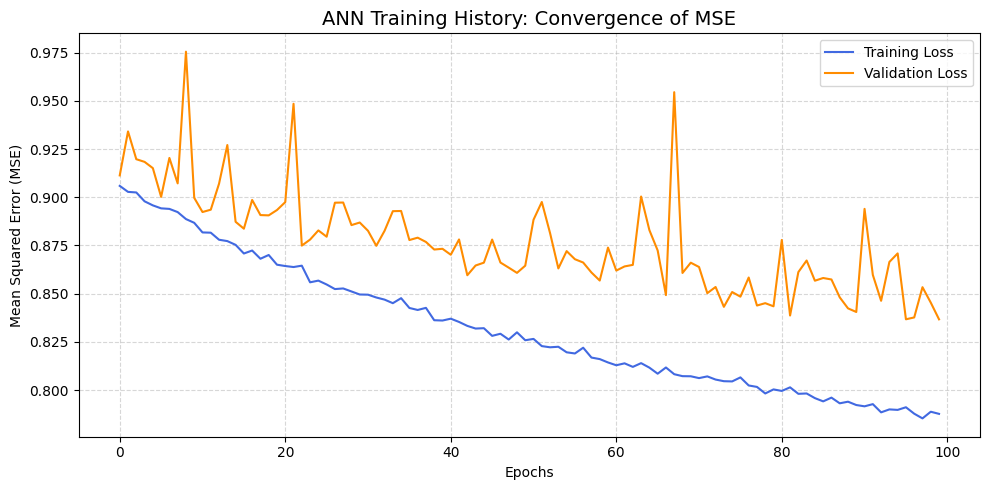

In [ ]:
# 7. Plot 1: Training and Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss', color='royalblue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='darkorange')
plt.title('ANN Training History: Convergence of MSE', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True, ls='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 184us/step


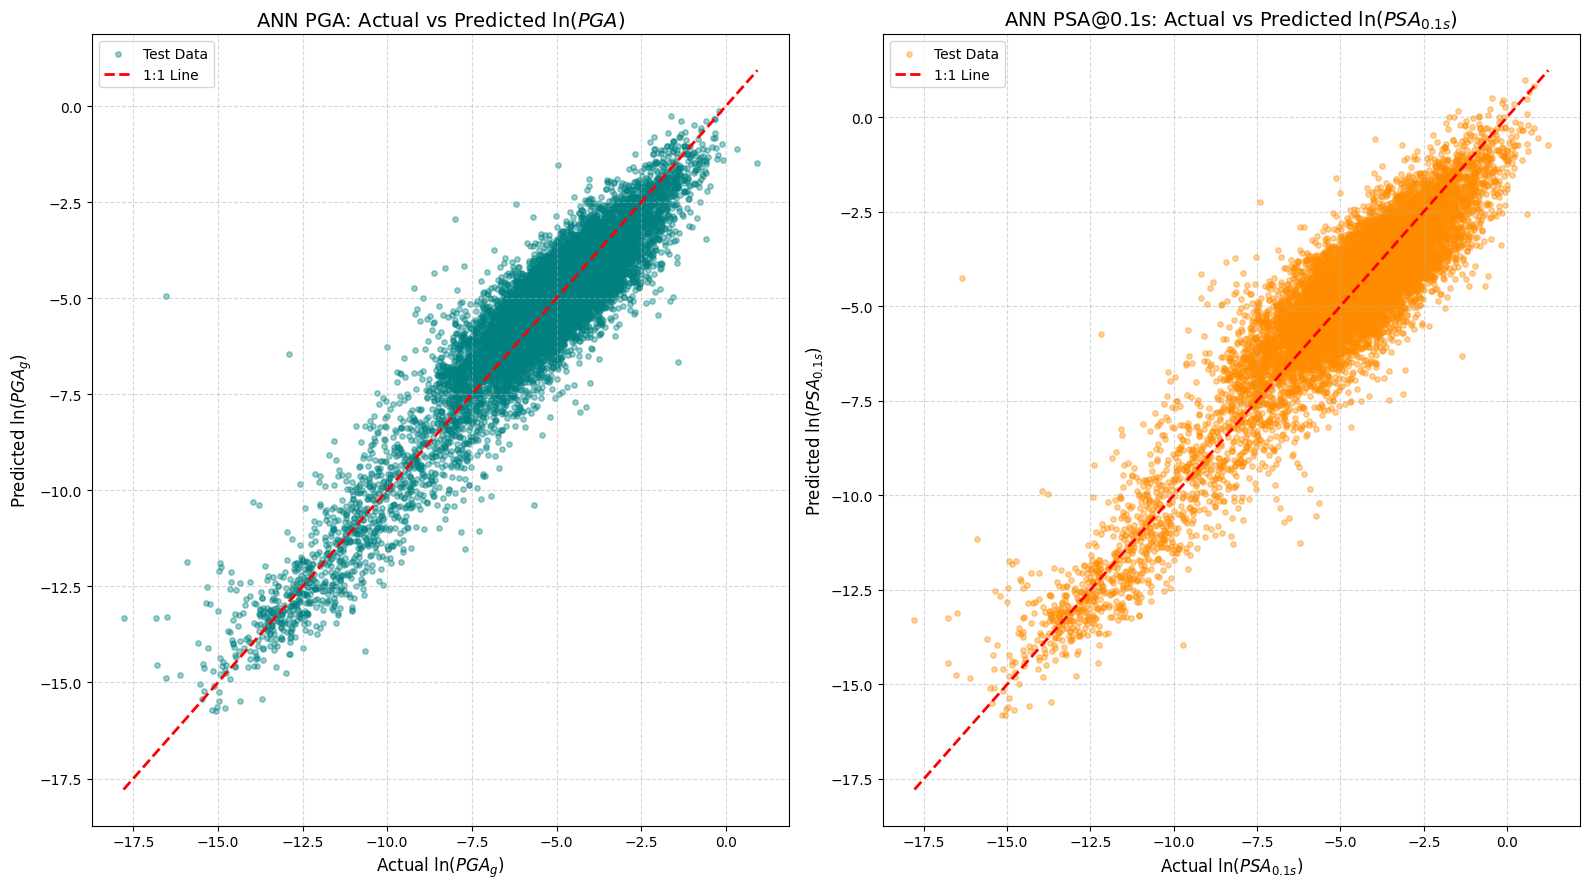

In [ ]:

# Actual vs Predicted
predictions = best_model.predict(X_test_scaled)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 9))

targets = ['PGA_g', 'T0pt100S']
titles = [r'ANN PGA: Actual vs Predicted $\ln(PGA)$', r'ANN PSA@0.1s: Actual vs Predicted $\ln(PSA_{0.1s})$']
labels = [r'Actual $\ln(PGA_g)$', r'Actual $\ln(PSA_{0.1s})$']
y_labels = [r'Predicted $\ln(PGA_g)$', r'Predicted $\ln(PSA_{0.1s})$']
colors = ['teal', 'darkorange']

for i, ax in enumerate([ax1, ax2]):
    actual = y_test.iloc[:, i]
    predicted = predictions[:, i]

    ax.scatter(actual, predicted, alpha=0.4, s=15, color=colors[i], label='Test Data')
    ax.plot([actual.min(), actual.max()], [actual.min(), actual.max()], 'r--', lw=2, label='1:1 Line')

    ax.set_title(titles[i], fontsize=14)
    ax.set_xlabel(labels[i], fontsize=12)
    ax.set_ylabel(y_labels[i], fontsize=12)
    ax.grid(True, ls='--', alpha=0.5)
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Evaluation Metrics
print(f"\nFinal ANN Performance Metrics:")
print(f"ANN PGA R^2 Score: {r2_score(y_test.iloc[:, 0], predictions[:, 0]):.4f}")
print(f"ANN PSA@0.1s R^2 Score: {r2_score(y_test.iloc[:, 1], predictions[:, 1]):.4f}")


Final ANN Performance Metrics:
ANN PGA R^2 Score: 0.8679
ANN PSA@0.1s R^2 Score: 0.8438
